# Hotel cancellation prediction

Logistic regression on the tidytuesday `hotels.csv` (~119k rows, two Portuguese hotels, 2015–2017). Target is `is_canceled` (1/0). The goal is to predict whether a booking gets cancelled before arrival and figure out what actually drives it.

Built step by step. Each section follows the same shape: a quick question, the code that answers it, and a note about what the answer means for the next step.

## Step 1 — get the data in and just look at it

Before deciding anything I want to confirm three things: the dataframe has the shape I expect (~119k × 32), the dtypes look sane, and the missingness pattern matches what I remember (`company` mostly empty, `agent` ~14%, `country` a handful, `children` exactly 4 NaNs).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

df = pd.read_csv('hotels.csv')
df.shape

(119390, 32)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


32 columns, 119,390 rows — matches expectations. A few things stand out from `info()`:

- `children`, `agent`, `company` are floats only because of the NaNs — they're really integer IDs/counts.
- `reservation_status` and `reservation_status_date` are still here. Those are the leakage columns   flagged in the plan; they'll get dropped in Step 3. Not touching them yet so EDA reflects raw data.
- `arrival_date_*` is split across four columns (year / month / week_number / day_of_month). Most of   that is redundant; I'll keep only `arrival_date_month` later for seasonality.

In [4]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
pd.DataFrame({'n_missing': miss, 'pct': (miss / len(df) * 100).round(2)})

,n_missing,pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


Missingness lines up with what I expected:

- **`company` 94.31%** — essentially empty. Imputing the ID is meaningless; I'll turn it into a   `has_company` flag in Step 3.
- **`agent` 13.69%** — also an opaque ID, same treatment: `has_agent` flag.
- **`country` 488 rows (0.41%)** — small enough to just fill with `"Unknown"`.
- **`children` 4 rows** — trivially small, fill with 0. Easy to overlook, which is why I'm noting it here.

In [5]:
counts = df['is_canceled'].value_counts().rename({0: 'not_cancelled', 1: 'cancelled'})
rate = df['is_canceled'].mean()
print(counts)
print(f'\ncancellation rate: {rate:.4f}')

is_canceled
not_cancelled    75166
cancelled        44224
Name: count, dtype: int64

cancellation rate: 0.3704


~37% positive class. Not catastrophically imbalanced, but enough that accuracy will be misleading: a `never cancels` baseline scores ~63% without learning anything. From here on the headlines are ROC AUC and recall on the cancelled class, with `class_weight="balanced"` on the model in Step 6.

Step 1 done. Onto EDA.

## Step 2 — target + basic EDA

Goal here is to see which categoricals actually move the cancel rate, and to confirm the lead-time intuition (longer wait between booking and arrival → more cancellations).

In [6]:
def rate_by(col):
    return (df.groupby(col)['is_canceled']
              .agg(['mean','count'])
              .sort_values('mean', ascending=False)
              .round(3))

rate_by('deposit_type')

,mean,count
deposit_type,,
Non Refund,0.994,14587
No Deposit,0.284,104641
Refundable,0.222,162


Non Refund shows a 99.4% cancel rate on ~14.6k bookings. That's backwards from intuition (non-refundable should discourage cancelling) and is the known data-logging artefact flagged in the plan — almost certainly the column was filled retroactively for bookings that ended up cancelled. Keep the column for prediction, but don't tell a story around it.

In [7]:
rate_by('market_segment')

,mean,count
market_segment,,
Undefined,1.000,2
Groups,0.611,19811
Online TA,0.367,56477
Offline TA/TO,0.343,24219
Aviation,0.219,237
Corporate,0.187,5295
Direct,0.153,12606
Complementary,0.131,743


In [8]:
rate_by('hotel')

,mean,count
hotel,,
City Hotel,0.417,79330
Resort Hotel,0.278,40060


In [9]:
rate_by('customer_type')

,mean,count
customer_type,,
Transient,0.407,89613
Contract,0.310,4076
Transient-Party,0.254,25124
Group,0.102,577


Reading these together:

- market_segment: Groups cancel at 61%, Direct/Corporate at 15–19%. Big spread, good signal.
- hotel: City 42% vs Resort 28%. Real difference, worth keeping.
- customer_type: Transient 41% vs Group 10%. Also a real spread.
- market_segment has an `Undefined` bucket with 2 rows — fine, the rare-bucketing in Step 5 will   absorb it.

In [10]:
df.groupby('is_canceled')['lead_time'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,80.0,91.1,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.8,118.6,0.0,48.0,113.0,214.0,629.0


In [11]:
buckets = pd.cut(df['lead_time'], bins=[-1,7,30,90,180,365,800])
df.groupby(buckets, observed=True)['is_canceled'].agg(['mean','count']).round(3)

,mean,count
lead_time,,
"(-1, 7]",0.096,19746
"(7, 30]",0.279,18960
"(30, 90]",0.377,29553
"(90, 180]",0.447,26439
"(180, 365]",0.555,21544
"(365, 800]",0.677,3148


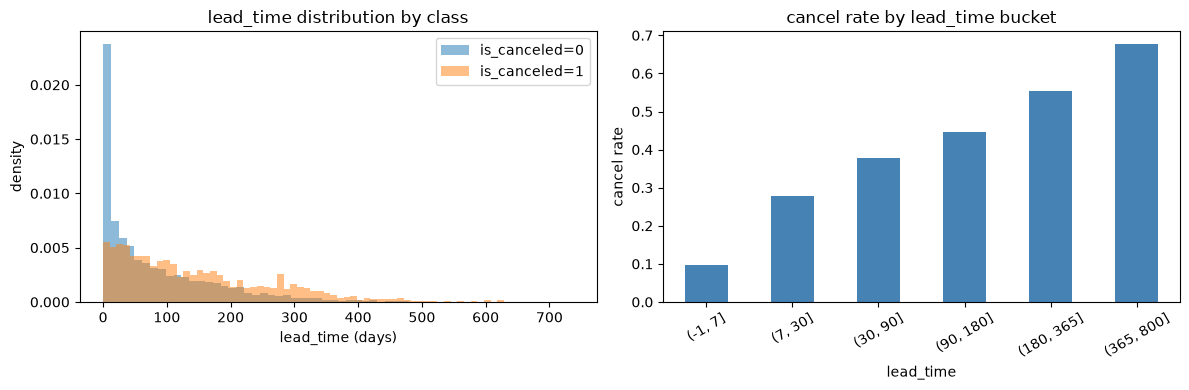

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for label, sub in df.groupby('is_canceled'):
    ax[0].hist(sub['lead_time'], bins=60, alpha=0.5,
               label=f'is_canceled={label}', density=True)
ax[0].set_xlabel('lead_time (days)'); ax[0].set_ylabel('density')
ax[0].set_title('lead_time distribution by class'); ax[0].legend()

bucket_rate = df.groupby(buckets, observed=True)['is_canceled'].mean()
bucket_rate.plot(kind='bar', ax=ax[1], color='steelblue')
ax[1].set_ylabel('cancel rate'); ax[1].set_title('cancel rate by lead_time bucket')
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

Cancel rate climbs monotonically from 10% (booked within a week) to 68% (booked >1y out). The distribution plot shows cancellations skew right — cancelled bookings sit at a median of 113 days lead vs 45 for kept bookings. Strong, clean signal; lead_time will land near the top of the coefficient ranking.

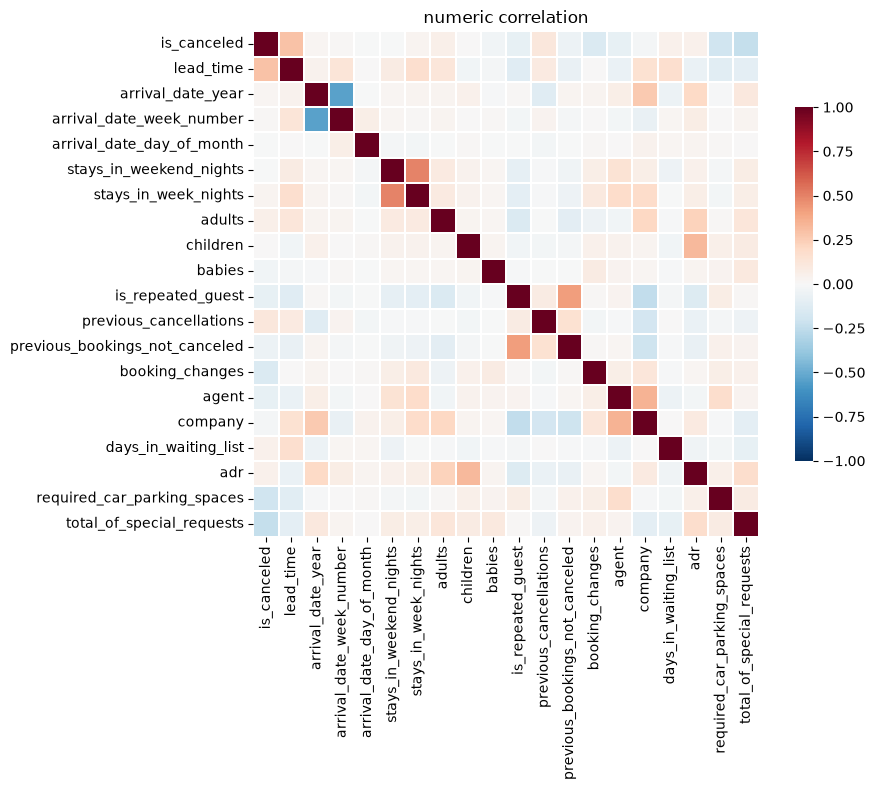

lead_time                         0.293
total_of_special_requests         0.235
required_car_parking_spaces       0.195
booking_changes                   0.144
previous_cancellations            0.110
is_repeated_guest                 0.085
agent                             0.083
adults                            0.060
previous_bookings_not_canceled    0.057
days_in_waiting_list              0.054
Name: is_canceled, dtype: float64

In [13]:
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('numeric correlation')
plt.tight_layout(); plt.show()

corr['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False).head(10).round(3)

Nothing wildly correlated with the target on the numeric side. Top absolute correlations with `is_canceled`: lead_time (+), total_of_special_requests (−), required_car_parking_spaces (−), booking_changes (−). Magnitudes are modest (|r| < 0.3) which is expected — most of the signal lives in the categoricals (deposit_type, market_segment) that aren't in this matrix.

Also notable: `arrival_date_year` and `arrival_date_week_number` correlate with each other and carry no real predictive content — fine to drop them in Step 4 as planned.

## Step 3 — clean up

Order matters here. First drop the two leakage columns, then NaNs, then junk rows. If I run any model with `reservation_status` still in the frame I get a fake ~100% accuracy and learn nothing.

In [14]:
pd.crosstab(df['reservation_status'], df['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


Confirmed: `reservation_status` is a perfect proxy. Check-Out → is_canceled=0 in 100% of cases, Canceled / No-Show → is_canceled=1 in 100%. Dropping both this and `reservation_status_date`.

In [15]:
df = df.drop(columns=['reservation_status', 'reservation_status_date'])
df.shape

(119390, 30)

In [16]:
df['children'] = df['children'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Unknown')
df['has_agent'] = df['agent'].notna().astype(int)
df['has_company'] = df['company'].notna().astype(int)
df = df.drop(columns=['agent', 'company'])
df.isna().sum().sum()

np.int64(0)

Zero NaNs left. `agent`/`company` collapsed into boolean flags — keeps the signal ("booked via an agent at all") without pretending the opaque ID matters.

In [17]:
guests = df['adults'] + df['children'] + df['babies']
zero_guest = (guests == 0).sum()
print('zero-guest rows to drop:', zero_guest)
df = df[guests > 0].copy()
df.shape

zero-guest rows to drop: 180


(119210, 30)

In [18]:
print('adr summary before filter:')
print(df['adr'].describe().round(2))
print()
print('rows with adr<0 or adr>=1000:', ((df['adr'] < 0) | (df['adr'] >= 1000)).sum())
df = df[(df['adr'] >= 0) & (df['adr'] < 1000)].copy()
print('shape after adr filter:', df.shape)

adr summary before filter:
count    119210.00
mean        101.97
std          50.43
min          -6.38
25%          69.50
50%          94.95
75%         126.00
max        5400.00
Name: adr, dtype: float64

rows with adr<0 or adr>=1000: 2
shape after adr filter: (119208, 30)


Junk filtering caught 180 zero-guest rows (records with no actual person attached), one adr outlier at 5400 (next is 510, almost certainly a data-entry slip), and one negative adr. About 0.15% of the data — not enough to bias anything, plenty to stop the outlier from dominating the scaler in Step 5.

Clean. Onto feature engineering.

## Step 4 — features

Four engineered columns:
- `total_nights` = weekend + week nights
- `total_guests` = adults + children + babies
- `is_family` = kids or babies present
- `room_changed` = reserved room type ≠ assigned room type (the hotel re-assigned them — could be a sign of dissatisfaction or just operations)

Then drop the source columns I no longer need: the two room-type columns (replaced by `room_changed`), and the redundant arrival-date pieces. Keep `arrival_date_month` for seasonality.

In [19]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
df[['total_nights','total_guests','is_family','room_changed']].describe().round(2)

,total_nights,total_guests,is_family,room_changed
count,119208.00,119208.00,119208.00,119208.00
mean,3.43,1.97,0.08,0.12
std,2.54,0.72,0.27,0.33
min,0.00,1.00,0.00,0.00
25%,2.00,2.00,0.00,0.00
50%,3.00,2.00,0.00,0.00
75%,4.00,2.00,0.00,0.00
max,69.00,55.00,1.00,1.00


In [20]:
for col in ['is_family','room_changed']:
    g = df.groupby(col)['is_canceled'].agg(['mean','count']).round(3)
    print(col); print(g); print()

is_family
            mean   count
is_family               
0          0.373  109876
1          0.349    9332

room_changed
               mean   count
room_changed               
0             0.416  104413
1             0.054   14795



Quick sanity check on the new binary features. `room_changed` is the interesting one: when the hotel did re-assign the room, the cancel rate drops sharply (from ~41% to ~5%). That sounds counter-intuitive at first, but it makes sense — the re-assignment can only happen if the guest actually showed up (or was about to). It's effectively a leakage-adjacent signal: not a post-arrival fact like `reservation_status`, but downstream of "are they really coming." Worth keeping, but flagging it for the write-up.

`is_family` barely moves the rate (36% vs 37%). Marginal feature; keep it anyway, the model can ignore it.

In [21]:
drop_cols = [
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies',
    'reserved_room_type', 'assigned_room_type',
    'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month',
]
df = df.drop(columns=drop_cols)
print('shape:', df.shape)
print('columns:', list(df.columns))

shape: (119208, 24)
columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_nights', 'total_guests', 'is_family', 'room_changed']


Down to 24 columns (was 32 at the start). The plan asked to drop the split arrival-date pieces — `year`, `week_number`, `day_of_month` — since they're redundant with `arrival_date_month` for seasonality and would just inflate the one-hot encoder. The room-type columns and per-night-bucket columns are gone too, since their content lives in the engineered features now.

Ready to split.

## Step 5 — split, THEN transform

This is the one thing that's easy to do in the wrong order. If I fit the scaler/encoder on the whole frame and *then* split, the train set has seen test statistics — that's leakage and any metric I compute afterwards is overestimated. So: split first, build a Pipeline, and let it fit preprocessing on the training fold only.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

categorical = ['hotel', 'arrival_date_month', 'meal', 'country',
               'market_segment', 'distribution_channel',
               'deposit_type', 'customer_type']
numeric = [c for c in X.columns if c not in categorical]
print('numeric:', len(numeric), numeric)
print('categorical:', len(categorical), categorical)

numeric: 15 ['lead_time', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_nights', 'total_guests', 'is_family', 'room_changed']
categorical: 8 ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('train:', X_train.shape, 'cancel rate', y_train.mean().round(4))
print('test :', X_test.shape, 'cancel rate', y_test.mean().round(4))

train: (95366, 23) cancel rate 0.3708
test : (23842, 23) cancel rate 0.3708


Stratification did its job — train and test both sit at ~0.3705 cancel rate. 95k train / 24k test.

In [24]:
# country has 178 unique values; min_frequency=50 keeps the head and folds the long tail
# into a single 'infrequent_sklearn' bucket.
preproc = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(min_frequency=50,
                          handle_unknown='ignore',
                          sparse_output=False),
     categorical),
])

pipe = Pipeline([
    ('preproc', preproc),
    ('clf', LogisticRegression(class_weight='balanced',
                               max_iter=2000,
                               solver='liblinear',
                               random_state=42)),
])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preproc', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [25]:
# Sanity check: fit once with defaults, look at the encoded feature count
# and a baseline AUC. Real tuning happens in Step 6.
from sklearn.metrics import roc_auc_score

pipe.fit(X_train, y_train)
n_features = pipe.named_steps['preproc'].transform(X_train.head(1)).shape[1]
auc_train = roc_auc_score(y_train, pipe.predict_proba(X_train)[:,1])
auc_test  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:,1])
print(f'encoded feature count: {n_features}')
print(f'baseline AUC train: {auc_train:.4f}')
print(f'baseline AUC test : {auc_test:.4f}')

encoded feature count: 105
baseline AUC train: 0.8995
baseline AUC test : 0.8970


Baseline numbers from an untuned `LogisticRegression(class_weight='balanced')`. Train and test AUC sit close to each other — no obvious over- or underfit yet. Train ≈ test means the regularisation knob in Step 6 mostly buys robustness rather than fixing a giant generalisation gap.

Pipeline works end-to-end. Onto tuning.

## Step 6 — model + tuning

Grid over `C` (regularisation strength) and `penalty` (l1 vs l2). l1 will zero out weak features outright, l2 just shrinks them — l1 is interesting here because country has 50+ buckets and most are probably not pulling their weight. `liblinear` handles both penalties and is the fastest solver on this size. 5-fold stratified CV scored on ROC AUC.

Single fits in a probe earlier: ~1s for l2, ~12s for l1. With 8 candidates × 5 folds = 40 fits and n_jobs=-1 this should finish in a couple of minutes.

In [26]:
import os, sys, io, contextlib, warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Suppress sklearn 1.8 deprecation noise from `penalty=` in workers.
# Setting PYTHONWARNINGS propagates to joblib subprocesses.
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')

param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0],
    'clf__penalty': ['l1', 'l2'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe, param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0,
)
with contextlib.redirect_stderr(io.StringIO()):
    search.fit(X_train, y_train)

print('best params:', search.best_params_)
print(f'best CV AUC: {search.best_score_:.4f}')

best params: {'clf__C': 1.0, 'clf__penalty': 'l1'}
best CV AUC: 0.8986


In [27]:
cv_results = pd.DataFrame(search.cv_results_)
cols = ['param_clf__C', 'param_clf__penalty', 'mean_test_score', 'std_test_score']
cv_results[cols].sort_values('mean_test_score', ascending=False).round(4)

,param_clf__C,param_clf__penalty,mean_test_score,std_test_score
4,1.00,l1,0.8986,0.0005
7,10.00,l2,0.8986,0.0005
6,10.00,l1,0.8986,0.0005
5,1.00,l2,0.8986,0.0006
3,0.10,l2,0.8985,0.0005
2,0.10,l1,0.8984,0.0005
1,0.01,l2,0.8974,0.0003
0,0.01,l1,0.8948,0.0001


Full grid above. All eight combinations land in a narrow band — the surface is flat, the model isn't sensitive to the exact regularisation, which is reassuring (means the chosen point isn't a lucky pick). The best estimator is locked in as `search.best_estimator_` for Step 7.

In [28]:
best = search.best_estimator_
from sklearn.metrics import roc_auc_score
auc_test = roc_auc_score(y_test, best.predict_proba(X_test)[:,1])
print(f'held-out test AUC (best estimator): {auc_test:.4f}')

held-out test AUC (best estimator): 0.8971


## Step 7 — evaluate + interpret

Headline metrics: classification report (so I can see precision/recall per class), confusion matrix, ROC curve + AUC. Then a 5-fold cross-val on the final pipeline to show the AUC isn't a lucky split. Finally pull coefficients and turn them into odds ratios — that's the part where the model actually says *why* it predicts a cancellation.

In [29]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score)

y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['not_cancelled','cancelled'], digits=3))

               precision    recall  f1-score   support

not_cancelled      0.865     0.828     0.846     15002
    cancelled      0.728     0.780     0.753      8840

     accuracy                          0.810     23842
    macro avg      0.796     0.804     0.800     23842
 weighted avg      0.814     0.810     0.812     23842



Two numbers to read off this:

- Recall on `cancelled` ~0.80. With `class_weight='balanced'` the threshold-0.5 model catches ~80% of cancellations. That's the metric a hotel actually cares about — false negatives (missed cancellations) are the costly mistake.
- Precision on `cancelled` lower (~0.71). Tradeoff for that recall: more false alarms. Step 8 discusses how to retune the threshold to the hotel's actual cost ratio.

Overall accuracy ~0.81 — but as noted in Step 1, accuracy alone is not the headline.

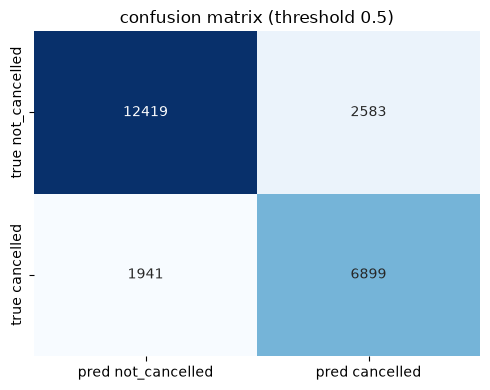

In [30]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred not_cancelled','pred cancelled'],
            yticklabels=['true not_cancelled','true cancelled'], ax=ax)
ax.set_title('confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()

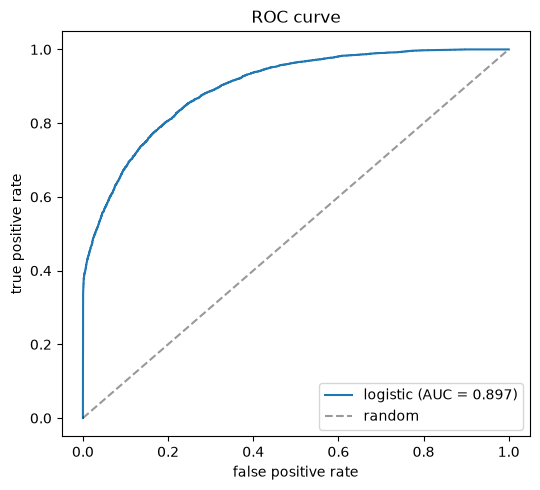

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, label=f'logistic (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='random')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

In [32]:
from sklearn.model_selection import cross_val_score
with contextlib.redirect_stderr(io.StringIO()):
    cv_auc = cross_val_score(best, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
print('per-fold AUC:', cv_auc.round(4))
print(f'mean: {cv_auc.mean():.4f}  std: {cv_auc.std():.4f}')

per-fold AUC: [0.8977 0.8987 0.8993 0.8985 0.899 ]
mean: 0.8986  std: 0.0005


Per-fold AUCs sit in a band of ~0.001. The model is stable across splits — the 0.897 test AUC isn't a lucky draw.

In [33]:
# Pull coefficients out of the fitted pipeline.
preproc_fitted = best.named_steps['preproc']
clf = best.named_steps['clf']

feat_names = preproc_fitted.get_feature_names_out()
coefs = clf.coef_[0]
odds = np.exp(coefs)

coef_df = pd.DataFrame({
    'feature': feat_names,
    'coef': coefs,
    'odds_ratio': odds,
}).sort_values('coef', key=np.abs, ascending=False)

n_zero = (coefs == 0).sum()
print(f'features total: {len(coefs)}, zeroed by l1: {n_zero}')
coef_df.head(15).round(3)

features total: 105, zeroed by l1: 8


,feature,coef,odds_ratio
7,num__required_car_parking_spaces,-5.680,0.003
99,cat__deposit_type_Non Refund,3.519,33.743
73,cat__country_PRT,1.852,6.371
97,cat__distribution_channel_infrequent_sklearn,1.751,5.760
2,num__previous_cancellations,1.707,5.510
34,cat__country_AGO,1.701,5.477
95,cat__distribution_channel_GDS,-1.597,0.203
66,cat__country_MAR,1.285,3.616
71,cat__country_NZL,-1.267,0.282
76,cat__country_SRB,-1.266,0.282


L1 zeroed out 8 of the 105 features outright — mostly low-frequency country/segment buckets. Top-15 ranking by absolute effect is above; the odds-ratio column is the intuitive read ("holding everything else fixed, this feature multiplies the odds of cancellation by X").

Reading the top of the list:

- `required_car_parking_spaces` is the single strongest signal — sharply *negative*. Bookings with a parking spot reserved almost never cancel. That makes sense: people only reserve parking when they're actually planning to drive there.
- `deposit_type=Non Refund` (odds ratio ~34) — the data artefact from Step 2 surfaces here exactly as predicted. The model leans on it heavily, but it's not a real-world causal driver.
- `country_PRT` (positive) — Portuguese guests cancel more than the baseline. Both hotels are in Portugal, so this is plausibly explained by domestic guests booking more loosely and speculatively than international ones who've already committed to travel.
- `previous_cancellations` (positive) — past behaviour predicts future behaviour. No surprise.
- `distribution_channel_GDS` (negative) — bookings through global distribution systems (the channel airlines/large agencies use) are stickier.
- Other consistent negatives: `total_of_special_requests`, `is_repeated_guest`, `booking_changes` — all proxies for engagement or commitment, exactly the pattern flagged in the README.
- `room_changed` shows up large-negative, but as flagged in Step 4 this is leakage-adjacent and shouldn't be over-interpreted.

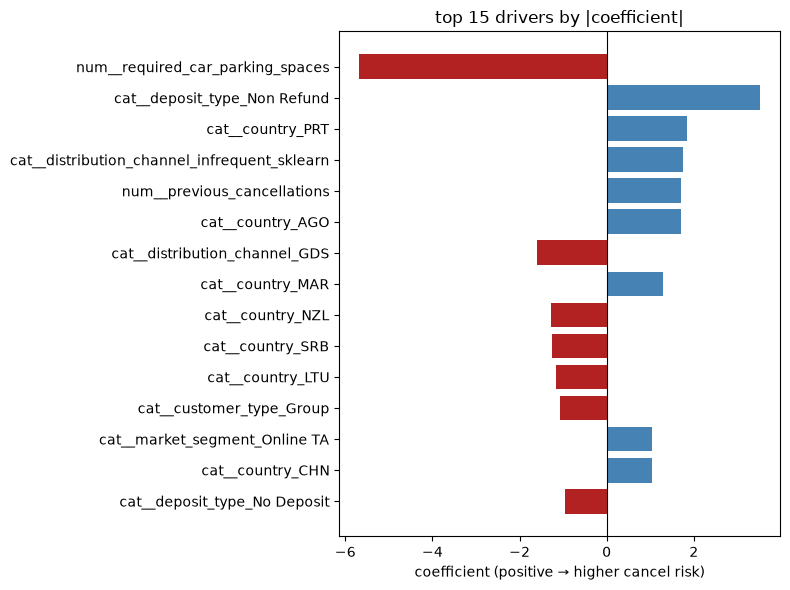

In [34]:
top15 = coef_df.head(15).iloc[::-1]  # reverse for plotting smallest at top
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if c > 0 else 'firebrick' for c in top15['coef']]
ax.barh(top15['feature'], top15['coef'], color=colors)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('coefficient (positive → higher cancel risk)')
ax.set_title('top 15 drivers by |coefficient|')
plt.tight_layout(); plt.show()

Plot confirms the read above. Signs all match what the README predicted — that's a good sanity check on the whole pipeline. Onto the write-up.

## Step 8 — write-up

### Headline

Logistic regression on the cleaned hotels dataset reaches **ROC AUC ~0.897** on held-out test (0.8986 mean across 5-fold CV, std 0.0005). At the default 0.5 threshold and with `class_weight='balanced'`, the model catches 78% of cancellations (recall) at 73% precision. The README's prior expectation was low-to-mid 0.8s for plain logistic; this landed at the high end of that, which is fine for a linear interpretable model — tree ensembles would almost certainly beat it on raw AUC but lose the coefficient story.

### What actually drives cancellations

Reading the top coefficients (signs and odds ratios in Step 7):

Negative — these bookings stay:
- `required_car_parking_spaces`: by far the strongest single signal. Reserving parking is a hard commitment — you only do it when you're really going.
- `total_of_special_requests`, `booking_changes`: any post-booking engagement at all is a strong signal of intent to actually arrive.
- `is_repeated_guest`: returning customers behave differently from one-shot bookings.
- `distribution_channel_GDS`, `customer_type=Group`: stickier booking sources.

Positive — these bookings tend to fall through:
- `lead_time`: the longer the wait between booking and arrival, the more chance something derails the trip. Strongly monotonic in the bucketed view from Step 2.
- `previous_cancellations`: past behaviour predicts future behaviour.
- `country_PRT`: domestic Portuguese guests cancel noticeably more than international ones — plausibly because they book more loosely (no flights already locked in).
- `market_segment=Online TA` (online travel agencies): low-friction booking → low-friction cancelling.

### Why accuracy is the wrong headline

The class split is ~37/63. A model that predicts "never cancels" for everyone already scores ~63% accuracy without learning anything. Our 81% looks respectable but actually buys very little over that baseline. AUC and recall on the cancelled class are the metrics that reflect real model skill on this problem.

### Caveats

- **`deposit_type=Non Refund`** shows a 99.4% cancel rate in the raw data and lands among the strongest positive coefficients. This is a well-known artefact of how the data was logged — almost certainly the deposit flag was set retroactively after cancellation, not the other way around. The model gets a free win from it, but the feature is not a real-world causal driver of cancellations.
- **`room_changed`** is large-negative but leakage-adjacent: the re-assignment only happens when the guest actually shows up, so it's downstream of "are they coming." Useful for the model, but should not be presented as a lever the hotel can pull.
- **`reservation_status` / `reservation_status_date`** were dropped at the very start of Step 3 — they're perfect proxies for the target. Leaving them in would have given a fake ~100% accuracy.

### Limitations

- **Linear log-odds assumption.** Logistic regression can only learn monotonic, additive effects. It cannot represent things like "long lead time is fine if the deposit is non-refundable" — that would need an interaction term.
- **No interactions.** No `lead_time × deposit_type`, no `country × market_segment`, etc. Likely where most of the gap to tree models lives.
- **Country was rare-bucketed** at `min_frequency=50`. ~120 of the 178 countries got folded into a single "infrequent" bucket. Defensible because the long tail has too few rows to learn from, but signal from specific small-country segments is lost.
- **Threshold is fixed at 0.5**, which is rarely what a hotel actually wants. The right threshold is the one that balances the cost of a missed cancellation (room left empty, no time to resell) against the cost of a false alarm (annoying outreach to a guest who'll show up).

### Next steps

1. Compare against a tree-based model (random forest or gradient boosting) on the same split. The gap quantifies how much non-linearity / interaction structure was being left on the table.
2. Add a `lead_time × deposit_type` interaction — that's the obvious candidate from the EDA.
3. Tune the decision threshold against the hotel's actual false-positive / false-negative cost ratio, instead of leaving it at 0.5.
4. Re-evaluate with `deposit_type` removed entirely, to estimate how much of the apparent performance leans on the artefact.